In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 10

print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Numpy version: 1.26.4
Pandas version: 2.2.2


In [2]:
# load data

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Define data path

data_path = os.path.join(project_root,'SMS_Spam_Classifier','dataset','spam.csv')

print(f"Project root: {project_root}")

print(f"Data Path: {data_path}")

print(f"Path Exists: {os.path.exists(data_path)}")
                               

Project root: C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects
Data Path: C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\SMS_Spam_Classifier\dataset\spam.csv
Path Exists: True


In [3]:
print(os.getcwd())

C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\SMS_Spam_Classifier


In [4]:
df = pd.read_csv(data_path, encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

## **1. Data Cleanig**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'],inplace = True)

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# renaming the columns

df.rename(columns = {'v1' : 'Target','v2' : 'Text'},inplace = True)
df.head()


,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# label encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Target'] = encoder.fit_transform(df['Target'])

In [11]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# missing values

df.isnull().sum()

Target    0
Text      0
dtype: int64

In [13]:
# check for duplicates

df.duplicated().sum()

403

In [14]:
# remove duplicates

df = df.drop_duplicates(keep = 'first')

In [15]:
df.duplicated().sum()

0

In [16]:
df.shape

(5169, 2)

# 2.EDA

In [17]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

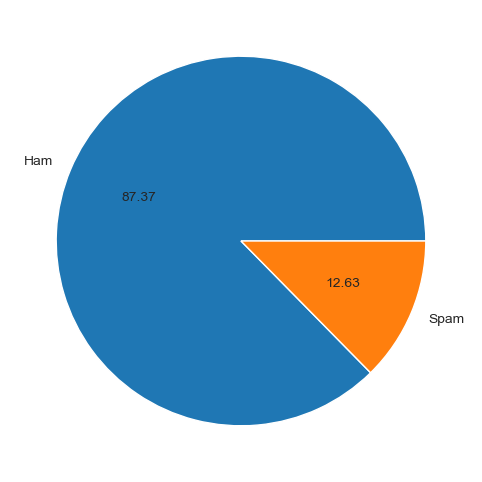

In [18]:
plt.pie(df['Target'].value_counts(), labels = ['Ham','Spam'],autopct = '%0.2f')
plt.show()

In [19]:
# Data is imbalanced

In [20]:
!pip install nltk
import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhagyashree.s\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
df['num_characters'] = df['Text'].apply(len)

In [22]:
df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
# number of words

df['num_words'] = df['Text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [24]:
df.head()

,Target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
# number of sentencess

df['num_sentenses'] = df['Text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.head()

,Target,Text,num_characters,num_words,num_sentenses
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
df['Text'].apply(lambda x : nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: Text, Length: 5169, dtype: object

In [27]:
df.describe()

,Target,num_characters,num_words,num_sentenses
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [28]:
# ham

df[df['Target'] == 0][['num_characters','num_words', 'num_sentenses']].describe()

,num_characters,num_words,num_sentenses
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# spam

df[df['Target'] == 1][['num_characters','num_words', 'num_sentenses']].describe()

,num_characters,num_words,num_sentenses
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

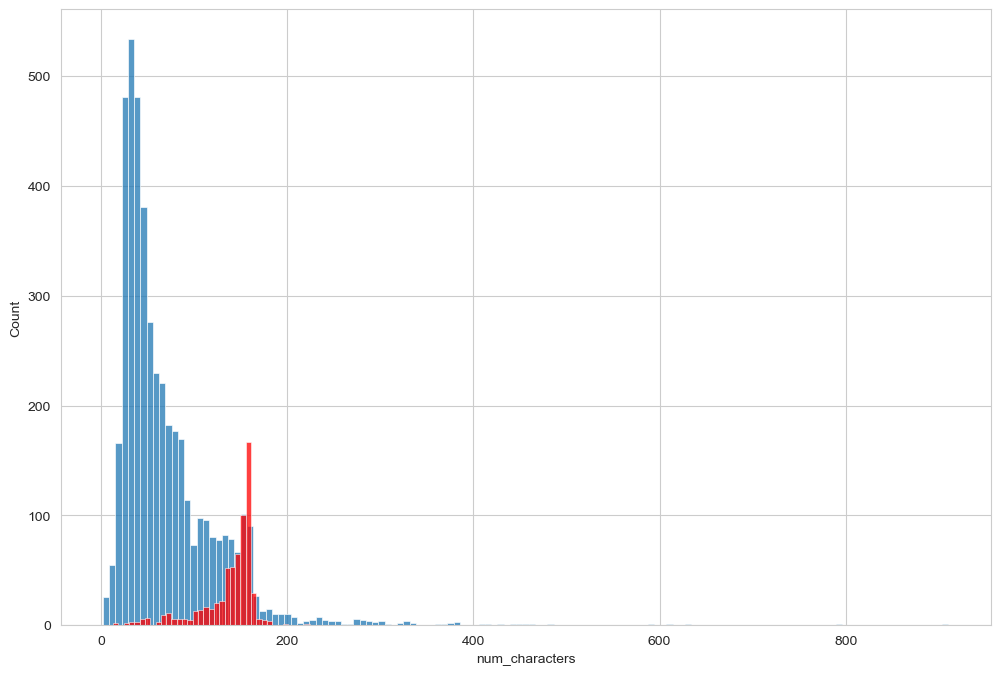

In [30]:
plt.figure(figsize = (12,8))

sns.histplot(df[df['Target'] == 0]['num_characters'])
sns.histplot(df[df['Target'] == 1]['num_characters'], color = 'red')


<Axes: xlabel='num_words', ylabel='Count'>

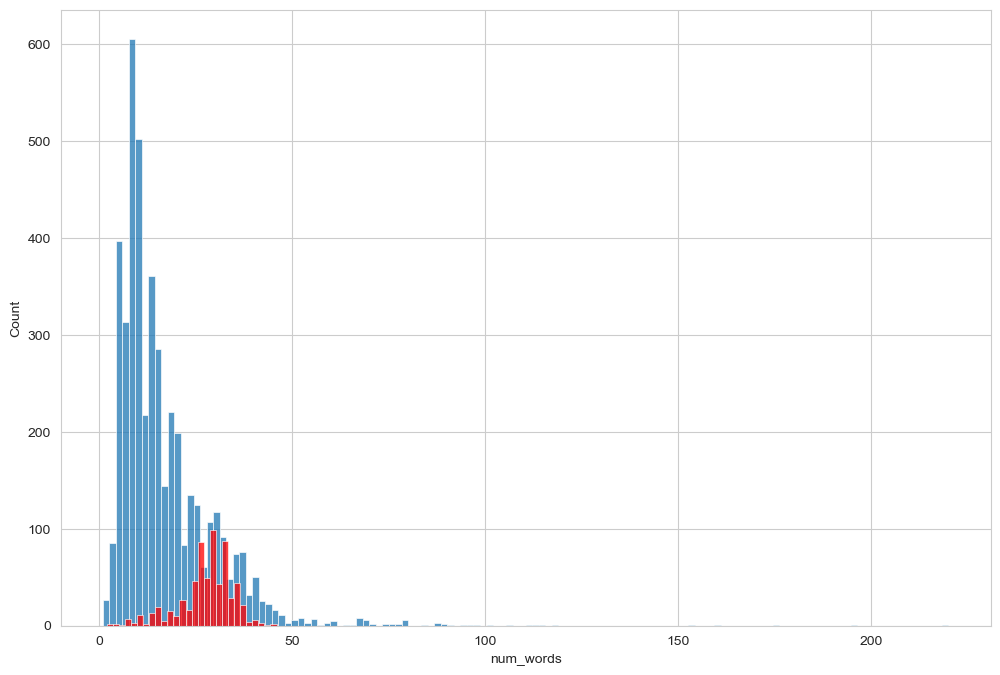

In [31]:
plt.figure(figsize = (12,8))

sns.histplot(df[df['Target'] == 0]['num_words'])
sns.histplot(df[df['Target'] == 1]['num_words'], color = 'red')

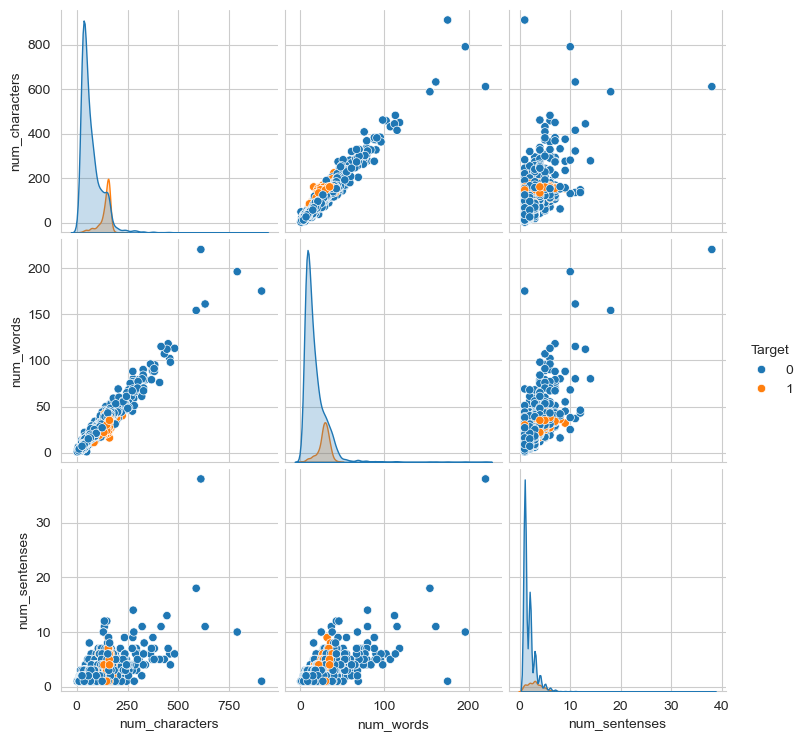

In [32]:
sns.pairplot(df,hue = 'Target')

<Axes: >

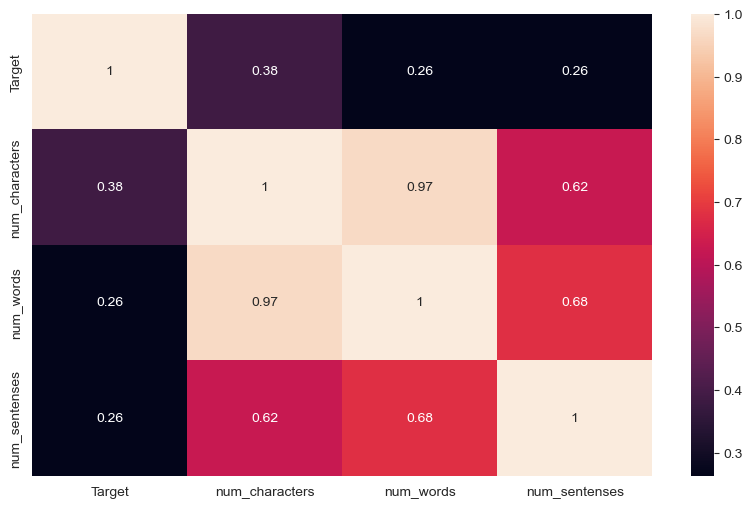

In [33]:
sns.heatmap(df[['Target','num_characters','num_words', 'num_sentenses']].corr(),annot = True)

# **3.Text Preprocessing**

- Lower case <br>
- Tokenization  <br>
- Removing Special characters  <br>
- Removing stop words and punctuation  <br>
- Stemming

In [34]:
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):

    # lowercase
    text = text.lower()

    # emoji removal
    text = re.sub(r'[^\w\s]', '', text)

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # tokenization
    words = nltk.word_tokenize(text)

    # remove special characters
    words = [word for word in words if word.isalnum()]

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # stemming
    words = [ps.stem(word) for word in words]

    return " ".join(words)

In [35]:
#transform_text('HI how aRE you Robin Klare, Is youR AGE IS 7 #$%^?')

In [36]:
#transform_text('I Loved the Youtube Lectures on AI&ML FRom Campus-X channel, How about You??')

In [37]:
#import string
#string.punctuation

In [38]:
#from nltk.corpus import stopwords
#stopwords.words('english')

In [39]:
# stemming
#from nltk.stem.porter import PorterStemmer
#ps = PorterStemmer()
#ps.stem('loving')

In [40]:
df['Text'][7]

"As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune"

In [41]:
#transform_text(df['Text'][7])

In [42]:
df['transformed_text'] = df['Text'].apply(transform_text)
df.head()

,Target,Text,num_characters,num_words,num_sentenses,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


In [43]:
# word cloud

from wordcloud import WordCloud

wc = WordCloud(width = 1000, height = 1000, min_font_size = 10, background_color = 'white')


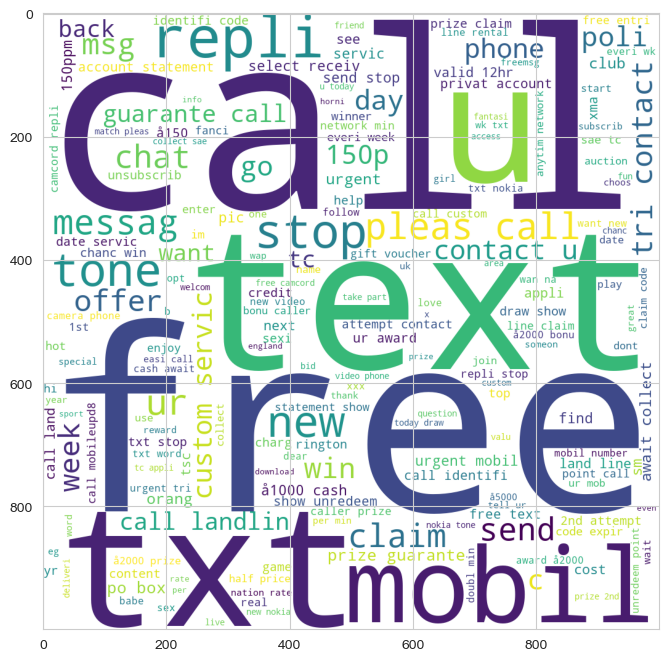

In [44]:
plt.figure(figsize = (18,8))
spam_wc = wc.generate(df[df['Target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.imshow(spam_wc)

In [45]:
# word cloud

from wordcloud import WordCloud

ham_wc = WordCloud(width = 1000, height = 1000, min_font_size = 10, background_color = 'white')


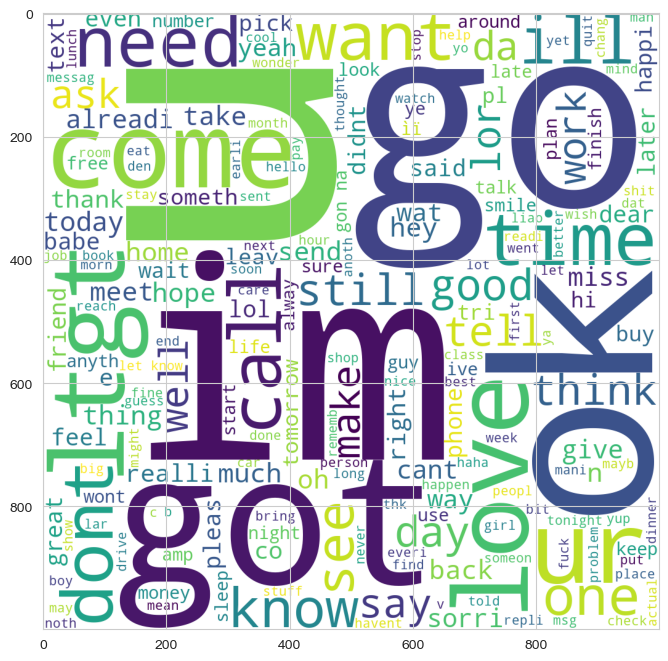

In [46]:
plt.figure(figsize = (18,8))
ham_wc = wc.generate(df[df['Target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.imshow(spam_wc)

In [47]:
#  converting snetence to list of  spam words

spam_corpus = []
for msg in df[df['Target']== 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
#spam_corpus

In [48]:
len(spam_corpus)

10793

In [49]:
from collections import Counter
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))
top_words

,0,1
0,call,321
1,free,188
2,2,155
3,txt,137
4,u,123
5,text,121
6,ur,119
7,mobil,114
8,stop,103
9,repli,100


In [50]:
df.head()

,Target,Text,num_characters,num_words,num_sentenses,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


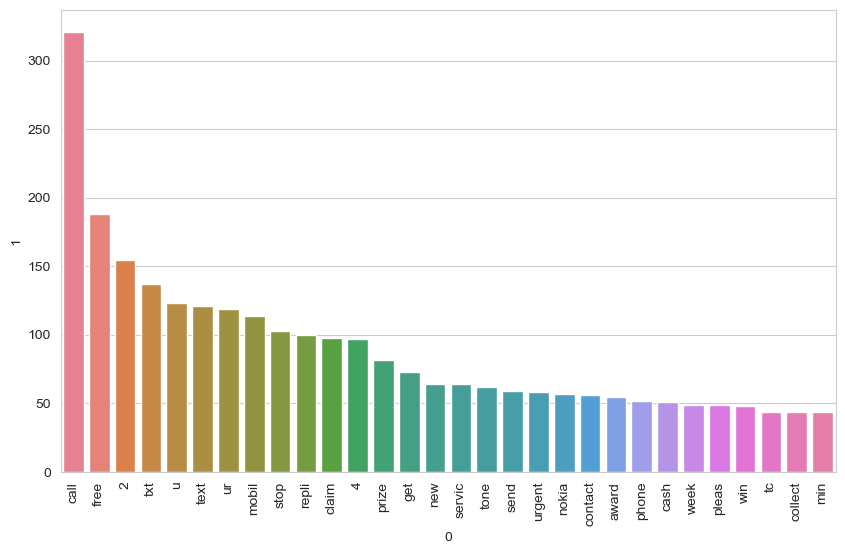

In [51]:
from collections import Counter
sns.barplot(x = top_words[0], y = top_words[1], hue = top_words[0])
plt.xticks(rotation = 'vertical')
plt.show()

## **4. Model Building**

#### Vectorizing -> BOW[bag Of Word]

In [52]:
# Vectorizing
# using bag of word

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()


In [53]:
X = cv.fit_transform(df['transformed_text']).toarray()
X.shape

(5169, 8041)

In [54]:
y = df['Target']
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Target, Length: 5169, dtype: int32

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size = 0.2, random_state = 42) 

In [56]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [57]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [58]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred1)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred1)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred1)}')
      


Accuracy : 0.8762088974854932
-----------------------------------
Confusion Matrix : [[779 110]
 [ 18 127]]
-----------------------------------
Precision score :0.5358649789029536


In [59]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred2)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred2)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred2)}')
      


Accuracy : 0.9748549323017408
-----------------------------------
Confusion Matrix : [[875  14]
 [ 12 133]]
-----------------------------------
Precision score :0.9047619047619048


In [60]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred3)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred3)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred3)}')
      


Accuracy : 0.9690522243713733
-----------------------------------
Confusion Matrix : [[886   3]
 [ 29 116]]
-----------------------------------
Precision score :0.9747899159663865


#### Vectorizing -> TF - IDF

In [61]:
# TF - IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [62]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
X.shape

(5169, 8041)

In [63]:
y = df['Target']
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Target, Length: 5169, dtype: int32

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size = 0.2, random_state = 42) 

In [65]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [66]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [67]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred1)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred1)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred1)}')
      

Accuracy : 0.874274661508704
-----------------------------------
Confusion Matrix : [[779 110]
 [ 20 125]]
-----------------------------------
Precision score :0.5319148936170213


In [68]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred2)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred2)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred2)}')
      


Accuracy : 0.9593810444874274
-----------------------------------
Confusion Matrix : [[889   0]
 [ 42 103]]
-----------------------------------
Precision score :1.0


In [69]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred3)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred3)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred3)}')
      


Accuracy : 0.9690522243713733
-----------------------------------
Confusion Matrix : [[886   3]
 [ 29 116]]
-----------------------------------
Precision score :0.9747899159663865


In [70]:
# selected model -> tfidf - mnb

### Comparing with other Algorithms

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [72]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [73]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb,  
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'ETC': etc,
    'xgb':xgb
}

In [74]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return accuracy, precision

In [75]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9748549323017408, 0.9612403100775194)

In [76]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print('For ', name)
    print(f'Accuracy of {name} : {current_accuracy}')
    print(f'Precision Score of {name} : {current_precision}')
    print('------------------------------')

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    
    

For  SVC
Accuracy of SVC : 0.9748549323017408
Precision Score of SVC : 0.9612403100775194
------------------------------
For  KN
Accuracy of KN : 0.8916827852998066
Precision Score of KN : 1.0
------------------------------
For  NB
Accuracy of NB : 0.9593810444874274
Precision Score of NB : 1.0
------------------------------
For  LR
Accuracy of LR : 0.9429400386847195
Precision Score of LR : 0.8839285714285714
------------------------------
For  RF
Accuracy of RF : 0.9632495164410058
Precision Score of RF : 0.9908256880733946
------------------------------
For  AdaBoost
Accuracy of AdaBoost : 0.9526112185686654
Precision Score of AdaBoost : 0.8636363636363636
------------------------------
For  ETC
Accuracy of ETC : 0.9729206963249516
Precision Score of ETC : 0.9915966386554622
------------------------------
For  xgb
Accuracy of xgb : 0.97678916827853
Precision Score of xgb : 0.984
------------------------------


In [77]:
performance_df = pd.DataFrame({'Algorithms' : clfs.keys() , 
                               'Accuracy' : accuracy_scores, 
                               'Precision' : precision_scores}).sort_values('Precision',ascending = False)
performance_df

,Algorithms,Accuracy,Precision
1,KN,0.891683,1.000000
2,NB,0.959381,1.000000
6,ETC,0.972921,0.991597
4,RF,0.963250,0.990826
7,xgb,0.976789,0.984000
0,SVC,0.974855,0.961240
3,LR,0.942940,0.883929
5,AdaBoost,0.952611,0.863636


In [78]:
performance_df1 = pd.melt(performance_df, id_vars = 'Algorithms')
performance_df1

,Algorithms,variable,value
0,KN,Accuracy,0.891683
1,NB,Accuracy,0.959381
2,ETC,Accuracy,0.972921
3,RF,Accuracy,0.963250
4,xgb,Accuracy,0.976789
5,SVC,Accuracy,0.974855
6,LR,Accuracy,0.942940
7,AdaBoost,Accuracy,0.952611
8,KN,Precision,1.000000
9,NB,Precision,1.000000


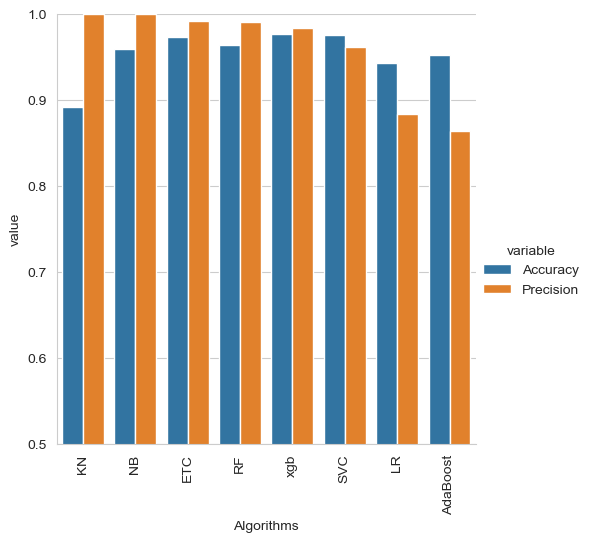

In [79]:
sns.catplot(x = 'Algorithms', y = 'value', hue = 'variable',
            data = performance_df1, kind = 'bar', height = 5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation = 'vertical')
plt.show()

In [80]:
df.head()

,Target,Text,num_characters,num_words,num_sentenses,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


### **Feature Engineering**

In [81]:
# model improve

# Step 1 — Create TF-IDF with 3000 features
# max_features=3000

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

In [92]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['Target']


In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size = 0.2, random_state = 42) 

In [94]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [95]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [96]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred1)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred1)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred1)}')
      

Accuracy : 0.8684719535783365
-----------------------------------
Confusion Matrix : [[776 113]
 [ 23 122]]
-----------------------------------
Precision score :0.5191489361702127


In [97]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred2)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred2)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred2)}')
      


Accuracy : 0.9748549323017408
-----------------------------------
Confusion Matrix : [[889   0]
 [ 26 119]]
-----------------------------------
Precision score :1.0


In [98]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test,y_pred3)}')
print('-----------------------------------')
print(f'Confusion Matrix : {confusion_matrix(y_test,y_pred3)}')
print('-----------------------------------')
print(f'Precision score :{ precision_score(y_test,y_pred3)}')

Accuracy : 0.9738878143133463
-----------------------------------
Confusion Matrix : [[888   1]
 [ 26 119]]
-----------------------------------
Precision score :0.9916666666666667


In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [100]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [101]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb,  
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'ETC': etc,
    'xgb':xgb
}

In [102]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return accuracy, precision

In [103]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print('For ', name)
    print(f'Accuracy of {name} : {current_accuracy}')
    print(f'Precision Score of {name} : {current_precision}')
    print('------------------------------')

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

For  SVC
Accuracy of SVC : 0.9748549323017408
Precision Score of SVC : 0.9473684210526315
------------------------------
For  KN
Accuracy of KN : 0.9052224371373307
Precision Score of KN : 1.0
------------------------------
For  NB
Accuracy of NB : 0.9748549323017408
Precision Score of NB : 1.0
------------------------------
For  LR
Accuracy of LR : 0.9458413926499033
Precision Score of LR : 0.8803418803418803
------------------------------
For  RF
Accuracy of RF : 0.9680851063829787
Precision Score of RF : 0.9827586206896551
------------------------------
For  AdaBoost
Accuracy of AdaBoost : 0.9584139264990329
Precision Score of AdaBoost : 0.875
------------------------------
For  ETC
Accuracy of ETC : 0.9738878143133463
Precision Score of ETC : 0.9758064516129032
------------------------------
For  xgb
Accuracy of xgb : 0.9680851063829787
Precision Score of xgb : 0.9516129032258065
------------------------------


In [104]:
# Step 1 — TFIDF max_features = 3000
df_maxft = pd.DataFrame({
    'Algorithms': clfs.keys(),
    'Accuracy_max_ft_3000': accuracy_scores,
    'Precision_max_ft_3000': precision_scores
})

new_df = performance_df.merge(df_maxft, on='Algorithms').sort_values('Precision_max_ft_3000', ascending=False)
new_df

,Algorithms,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.891683,1.000000,0.905222,1.000000
1,NB,0.959381,1.000000,0.974855,1.000000
3,RF,0.963250,0.990826,0.968085,0.982759
2,ETC,0.972921,0.991597,0.973888,0.975806
4,xgb,0.976789,0.984000,0.968085,0.951613
5,SVC,0.974855,0.961240,0.974855,0.947368
6,LR,0.942940,0.883929,0.945841,0.880342
7,AdaBoost,0.952611,0.863636,0.958414,0.875000


In [106]:
# Step 1 —> TFIDF max_features = 3000
# Step 2 -> # appending the num_character col to X
# X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

# step 3 ->#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)


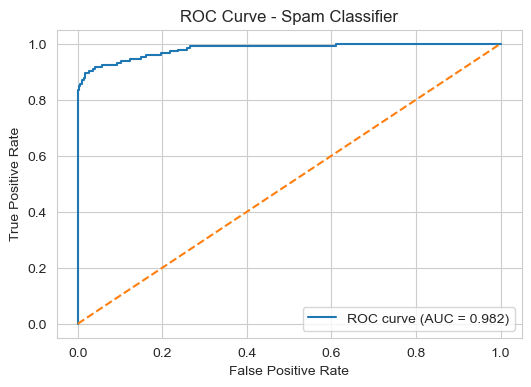

In [105]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# probability predictions
y_prob = mnb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.3f)' % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Spam Classifier')
plt.legend(loc="lower right")

plt.show()

In [ ]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [85]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],
                          voting='soft',
                         weights=[2,1,1])

In [86]:
voting.fit(X_train,y_train)


VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft', weights=[2, 1, 1])

In [87]:
y_pred = voting.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("Accuracy : ",accuracy_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("Recall : ", recall_score(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy :  0.9777562862669246
Precision :  0.9692307692307692
Recall :  0.8689655172413793
[[885   4]
 [ 19 126]]


In [107]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))